In [1]:
# import library
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

2023-10-14 18:31:08.577146: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
# load dataset with tf.keras
(train_images, train_labels), (test_images, test_labels) = tf.keras.datasets.mnist.load_data()
# print shape
print(train_images.shape,train_labels.shape, test_images.shape, test_labels.shape)

(60000, 28, 28) (60000,) (10000, 28, 28) (10000,)


index : 0
label :  5
image


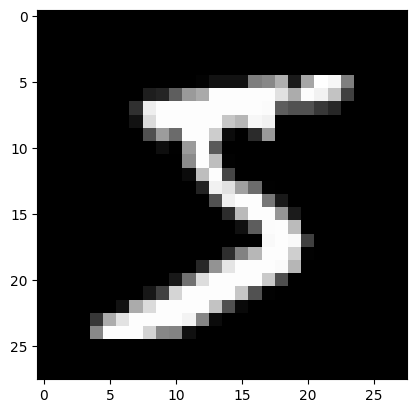

In [3]:
# check image
i = 0
print("index : " + str(i))
print("label : ", train_labels[i])
print("image")    
plt.imshow(train_images[i], cmap='gray')
plt.show()

In [4]:
# normalization
train_images = train_images/255.0
test_images = test_images/255.0

In [5]:
# input shape
input_shape=(28,28,1) # or (28,28)

In [13]:
# create model
model = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=(input_shape)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(100, activation='relu'),
    tf.keras.layers.Dense(10,activation=tf.keras.activations.softmax)
])

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten_4 (Flatten)         (None, 784)               0         
                                                                 
 dense_8 (Dense)             (None, 100)               78500     
                                                                 
 dense_9 (Dense)             (None, 10)                1010      
                                                                 
Total params: 79510 (310.59 KB)
Trainable params: 79510 (310.59 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


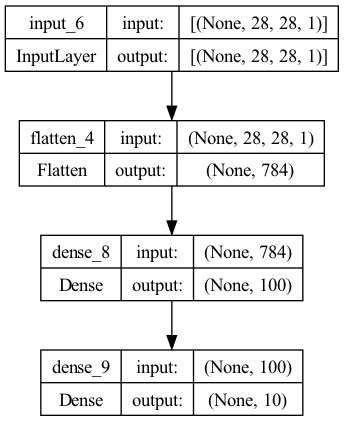

In [14]:
# check model
model.summary() 
# save model.summary
with open("model_summary.txt", "w") as f:
    model.summary(print_fn=lambda x: f.write(x + "\r\n"))
# plot model and save
tf.keras.utils.plot_model(model, show_shapes=True, show_layer_names=True, to_file='model.png')

In [15]:
# create model
model = tf.keras.models.Sequential()

# add layers 
model.add(tf.keras.layers.Input(shape=(input_shape)))
model.add(tf.keras.layers.Flatten())
model.add(tf.keras.layers.Dense(100, activation='relu'))
model.add(tf.keras.layers.Dense(10,activation=tf.keras.activations.softmax))

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten_5 (Flatten)         (None, 784)               0         
                                                                 
 dense_10 (Dense)            (None, 100)               78500     
                                                                 
 dense_11 (Dense)            (None, 10)                1010      
                                                                 
Total params: 79510 (310.59 KB)
Trainable params: 79510 (310.59 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


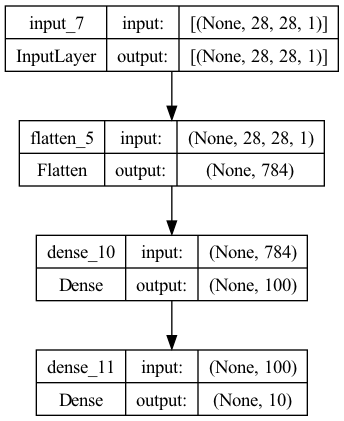

In [16]:
# check model
model.summary() 
# save model.summary
with open("model_summary.txt", "w") as f:
    model.summary(print_fn=lambda x: f.write(x + "\r\n"))
# plot model and save
tf.keras.utils.plot_model(model, show_shapes=True, show_layer_names=True, to_file='model.png')

In [17]:
# define layers
inputs = tf.keras.layers.Input(shape=(input_shape))
flatten = tf.keras.layers.Flatten()
fc_layer = tf.keras.layers.Dense(100, activation='relu')
output_layer = tf.keras.layers.Dense(10,activation=tf.keras.activations.softmax)

# define foward path 
x = flatten(inputs)
x = fc_layer(x)
outputs = output_layer(x)

# create model
model = tf.keras.Model(inputs=inputs, outputs=outputs)

Model: "model_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_8 (InputLayer)        [(None, 28, 28, 1)]       0         
                                                                 
 flatten_6 (Flatten)         (None, 784)               0         
                                                                 
 dense_12 (Dense)            (None, 100)               78500     
                                                                 
 dense_13 (Dense)            (None, 10)                1010      
                                                                 
Total params: 79510 (310.59 KB)
Trainable params: 79510 (310.59 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


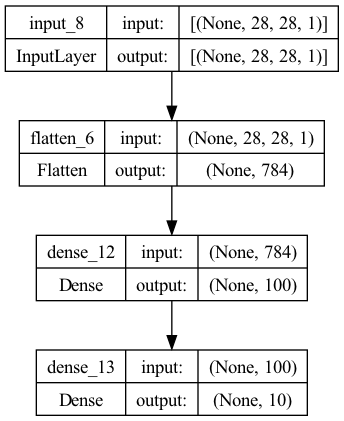

In [18]:
# check model
model.summary() 
# save model.summary
with open("model_summary.txt", "w") as f:
    model.summary(print_fn=lambda x: f.write(x + "\r\n"))
# plot model and save
tf.keras.utils.plot_model(model, show_shapes=True, show_layer_names=True, to_file='model.png')

In [19]:
# define layers and foward path
class DNN_tf(tf.keras.Model):
    def __init__(self, num_classes=10):
        super().__init__()
        self.flatten = tf.keras.layers.Flatten()
        self.fc_layer = tf.keras.layers.Dense(100, activation='relu')
        self.output_layer = tf.keras.layers.Dense(num_classes,activation=tf.keras.activations.softmax)
    def call(self, x):
        x = self.flatten(x)
        x = self.fc_layer(x)
        x = self.output_layer(x)
        return x

In [25]:
# create model
model = DNN_tf()

Model: "model_5"


_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_10 (InputLayer)       [(None, 28, 28, 1)]       0         
                                                                 
 flatten_8 (Flatten)         (None, 784)               0         
                                                                 
 dense_16 (Dense)            (None, 100)               78500     
                                                                 
 dense_17 (Dense)            (None, 10)                1010      
                                                                 
Total params: 79510 (310.59 KB)
Trainable params: 79510 (310.59 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


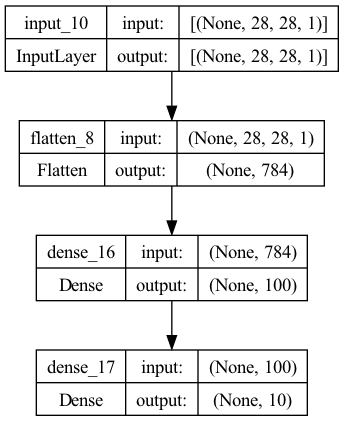

In [26]:
# make functional model from subclassing model for check
def get_functional_model(model):
  x = tf.keras.layers.Input(shape=(input_shape))
  model = tf.keras.Model(inputs=[x],outputs=model.call(x))
  return model

functional_model = get_functional_model(model)

functional_model.summary()
with open("model_summary.txt", "w") as f:
    functional_model.summary(print_fn=lambda x: f.write(x + "\r\n"))

tf.keras.utils.plot_model(functional_model, show_shapes=True, show_layer_names=True, to_file='model.png')

In [27]:
# define loss
loss = tf.keras.losses.SparseCategoricalCrossentropy()
# define optimizer
optimizer = tf.keras.optimizers.Adam()

In [28]:
# compile model
model.compile(loss=loss, optimizer=optimizer, metrics=['accuracy'])

In [29]:
# training
history = model.fit(train_images, train_labels,epochs=3)

Epoch 1/3
1875/1875 [==============================] - 6s 3ms/step - loss: 0.2817 - accuracy: 0.9197
Epoch 2/3
1875/1875 [==============================] - 7s 4ms/step - loss: 0.1316 - accuracy: 0.9606
Epoch 3/3
1875/1875 [==============================] - 7s 4ms/step - loss: 0.0919 - accuracy: 0.9735


In [30]:
# prediction
predictions = model(test_images)

index : 0
label :  7
predictions :  7
image


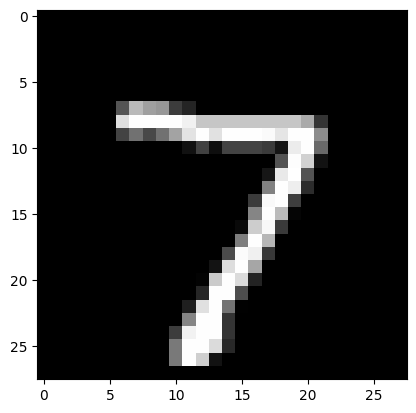

In [31]:
# check test label and prediction
i = 0
print("index : " + str(i))
print("label : ", test_labels[i])
print("predictions : ", np.argmax(predictions[i]))
print("image")    
plt.imshow(test_images[i], cmap='gray')
plt.show()